In [254]:
import numpy as np
import pandas as pd

data5000 = pd.read_csv('movie_metadata.csv')
data5000.head(20)

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0
5,Color,Andrew Stanton,462.0,132.0,475.0,530.0,Samantha Morton,640.0,73058679.0,Action|Adventure|Sci-Fi,...,738.0,English,USA,PG-13,263700000.0,2012.0,632.0,6.6,2.35,24000
6,Color,Sam Raimi,392.0,156.0,0.0,4000.0,James Franco,24000.0,336530303.0,Action|Adventure|Romance,...,1902.0,English,USA,PG-13,258000000.0,2007.0,11000.0,6.2,2.35,0
7,Color,Nathan Greno,324.0,100.0,15.0,284.0,Donna Murphy,799.0,200807262.0,Adventure|Animation|Comedy|Family|Fantasy|Musi...,...,387.0,English,USA,PG,260000000.0,2010.0,553.0,7.8,1.85,29000
8,Color,Joss Whedon,635.0,141.0,0.0,19000.0,Robert Downey Jr.,26000.0,458991599.0,Action|Adventure|Sci-Fi,...,1117.0,English,USA,PG-13,250000000.0,2015.0,21000.0,7.5,2.35,118000
9,Color,David Yates,375.0,153.0,282.0,10000.0,Daniel Radcliffe,25000.0,301956980.0,Adventure|Family|Fantasy|Mystery,...,973.0,English,UK,PG,250000000.0,2009.0,11000.0,7.5,2.35,10000


In [255]:
data5000.shape

(5043, 28)

### Let's remove unnecesary columns
---

In [256]:
data5000.columns

Index(['color', 'director_name', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes', 'actor_2_name',
       'actor_1_facebook_likes', 'gross', 'genres', 'actor_1_name',
       'movie_title', 'num_voted_users', 'cast_total_facebook_likes',
       'actor_3_name', 'facenumber_in_poster', 'plot_keywords',
       'movie_imdb_link', 'num_user_for_reviews', 'language', 'country',
       'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes',
       'imdb_score', 'aspect_ratio', 'movie_facebook_likes'],
      dtype='object')

In [257]:
needed_columns = [
    'movie_title',
    'title_year',
    'genres',
    'director_name',
    'actor_1_name',
    'actor_2_name',
    'actor_3_name',
    'imdb_score',
    'plot_keywords',
    'language',]
data5000 = data5000[needed_columns]
data5000.head(10)

,movie_title,title_year,genres,director_name,actor_1_name,actor_2_name,actor_3_name,imdb_score,plot_keywords,language
0,Avatar,2009.0,Action|Adventure|Fantasy|Sci-Fi,James Cameron,CCH Pounder,Joel David Moore,Wes Studi,7.9,avatar|future|marine|native|paraplegic,English
1,Pirates of the Caribbean: At World's End,2007.0,Action|Adventure|Fantasy,Gore Verbinski,Johnny Depp,Orlando Bloom,Jack Davenport,7.1,goddess|marriage ceremony|marriage proposal|pi...,English
2,Spectre,2015.0,Action|Adventure|Thriller,Sam Mendes,Christoph Waltz,Rory Kinnear,Stephanie Sigman,6.8,bomb|espionage|sequel|spy|terrorist,English
3,The Dark Knight Rises,2012.0,Action|Thriller,Christopher Nolan,Tom Hardy,Christian Bale,Joseph Gordon-Levitt,8.5,deception|imprisonment|lawlessness|police offi...,English
4,Star Wars: Episode VII - The Force Awakens ...,NaN,Documentary,Doug Walker,Doug Walker,Rob Walker,NaN,7.1,NaN,NaN
5,John Carter,2012.0,Action|Adventure|Sci-Fi,Andrew Stanton,Daryl Sabara,Samantha Morton,Polly Walker,6.6,alien|american civil war|male nipple|mars|prin...,English
6,Spider-Man 3,2007.0,Action|Adventure|Romance,Sam Raimi,J.K. Simmons,James Franco,Kirsten Dunst,6.2,sandman|spider man|symbiote|venom|villain,English
7,Tangled,2010.0,Adventure|Animation|Comedy|Family|Fantasy|Musi...,Nathan Greno,Brad Garrett,Donna Murphy,M.C. Gainey,7.8,17th century|based on fairy tale|disney|flower...,English
8,Avengers: Age of Ultron,2015.0,Action|Adventure|Sci-Fi,Joss Whedon,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,7.5,artificial intelligence|based on comic book|ca...,English
9,Harry Potter and the Half-Blood Prince,2009.0,Adventure|Family|Fantasy|Mystery,David Yates,Alan Rickman,Daniel Radcliffe,Rupert Grint,7.5,blood|book|love|potion|professor,English


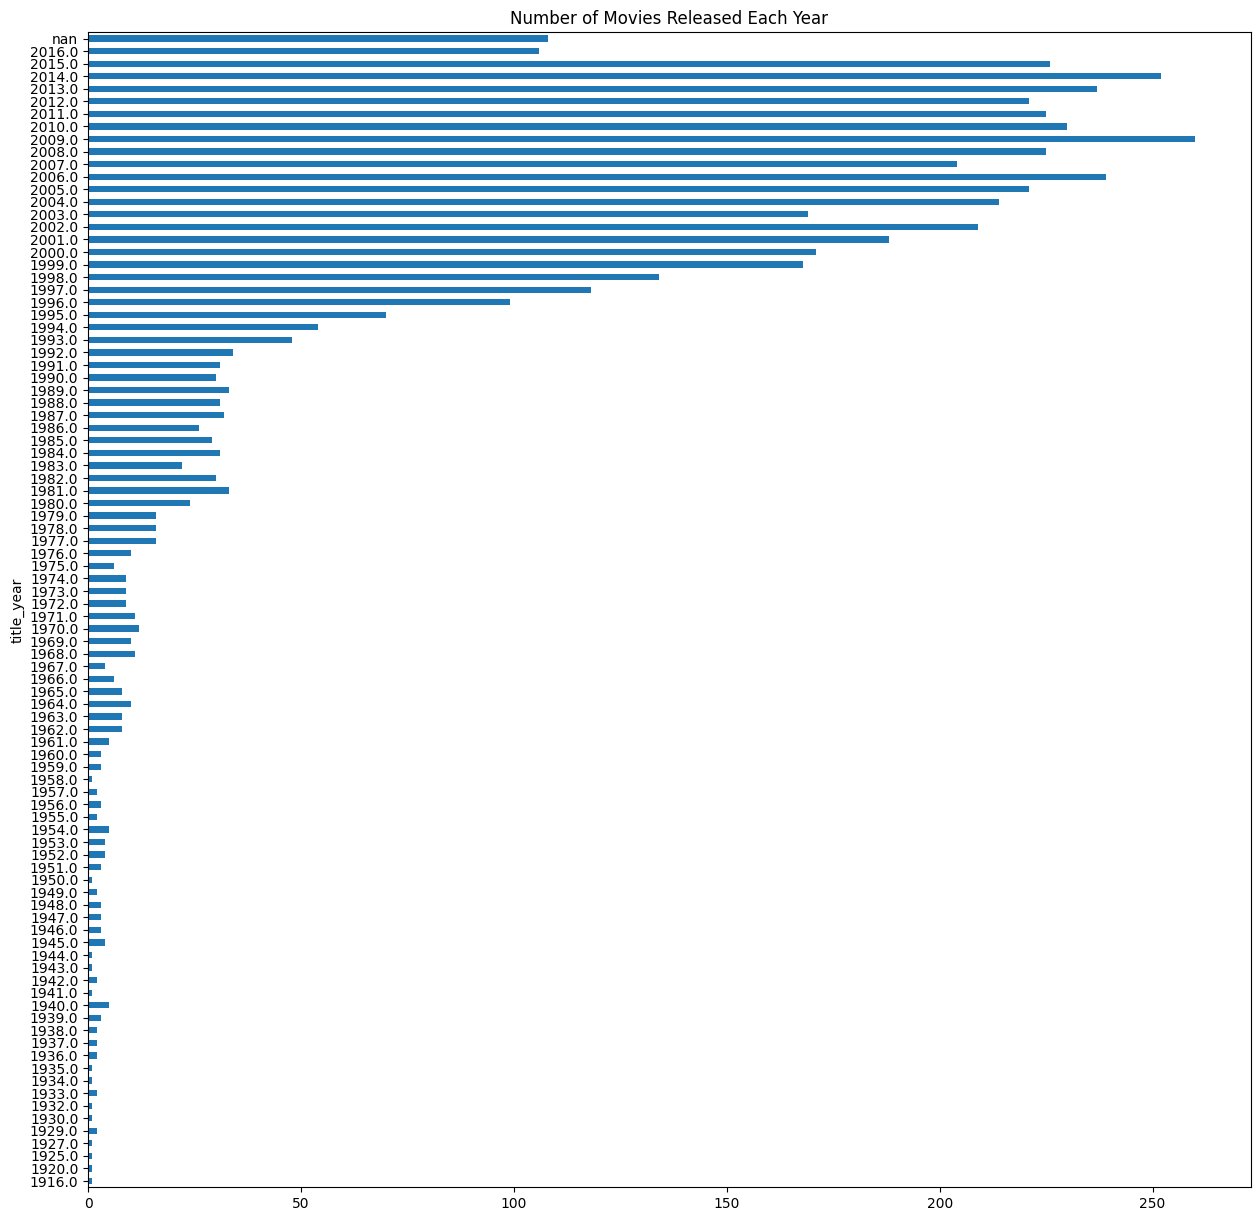

In [258]:
import matplotlib.pyplot as plt

data5000['title_year'].value_counts(dropna=False).sort_index().plot(kind='barh', figsize=(15, 15))
plt.title('Number of Movies Released Each Year')
plt.show()

## We have movies from 1916 to 2016, the rest is not included in the dataset.
### Let's look at the nan values and the earliest movie (out of curiosity)
---

In [259]:
data5000.dropna(subset=['title_year']).sort_values('title_year', ascending=True).head(10)

,movie_title,title_year,genres,director_name,actor_1_name,actor_2_name,actor_3_name,imdb_score,plot_keywords,language
4810,Intolerance: Love's Struggle Throughout the Ages,1916.0,Drama|History|War,D.W. Griffith,Lillian Gish,Mae Marsh,Walter Long,8.0,huguenot|intolerance|medicis|protestant|wedding,NaN
4958,Over the Hill to the Poorhouse,1920.0,Crime|Drama,Harry F. Millarde,Stephen Carr,Johnnie Walker,Mary Carr,4.8,family relationships|gang|idler|poorhouse|thief,NaN
4885,The Big Parade,1925.0,Drama|Romance|War,King Vidor,John Gilbert,Renée Adorée,Claire Adams,8.3,chewing gum|climbing a tree|france|translation...,NaN
2734,Metropolis,1927.0,Drama|Sci-Fi,Fritz Lang,Brigitte Helm,Gustav Fröhlich,Rudolf Klein-Rogge,8.3,art deco|bible quote|dance|silent film|worker,German
4812,The Broadway Melody,1929.0,Musical|Romance,Harry Beaumont,Anita Page,Bessie Love,Charles King,6.3,sibling rivalry|singer|sister act|whistling|wi...,English
4664,Pandora's Box,1929.0,Crime|Drama|Romance,Georg Wilhelm Pabst,Louise Brooks,Francis Lederer,Fritz Kortner,8.0,escape|femme fatale|german expressionism|lust|...,German
3960,Hell's Angels,1930.0,Drama|War,Howard Hughes,Jean Harlow,Marian Marsh,James Hall,7.8,bomb|bombing mission|munitions|oxford|royal fl...,English
3755,A Farewell to Arms,1932.0,Drama|Romance|War,Frank Borzage,Gary Cooper,Helen Hayes,Adolphe Menjou,6.6,1910s|ambulance driver|italy|lake|nurse,English
4898,She Done Him Wrong,1933.0,Comedy|Drama|History|Musical|Romance,Lowell Sherman,Mae West,Gilbert Roland,Louise Beavers,6.5,captain|marriage proposal|saloon|saloon singer...,English
4786,42nd Street,1933.0,Comedy|Musical|Romance,Lloyd Bacon,Ginger Rogers,Dick Powell,George Brent,7.7,chorus girl|chorus line|director|gala premiere...,English


In [260]:
data5000.query('title_year.isnull()').head(10)

,movie_title,title_year,genres,director_name,actor_1_name,actor_2_name,actor_3_name,imdb_score,plot_keywords,language
4,Star Wars: Episode VII - The Force Awakens ...,NaN,Documentary,Doug Walker,Doug Walker,Rob Walker,NaN,7.1,NaN,NaN
177,Miami Vice,NaN,Action|Crime|Drama|Mystery|Thriller,NaN,Don Johnson,Philip Michael Thomas,John Diehl,7.5,cult tv|detective|drugs|police|undercover,English
260,The A-Team,NaN,Action|Adventure|Crime,NaN,George Peppard,Dirk Benedict,Dwight Schultz,7.6,1980s|cult tv|famous opening theme|good versus...,English
279,"10,000 B.C.",NaN,Comedy,Christopher Barnard,Mathew Buck,NaN,NaN,7.2,NaN,NaN
404,Hannibal,NaN,Crime|Drama|Horror|Mystery|Thriller,NaN,Caroline Dhavernas,Scott Thompson,Hettienne Park,8.6,blood|cannibalism|fbi|manipulation|psychiatrist,English
459,Daredevil,NaN,Action|Adventure|Crime|Drama|Sci-Fi|Thriller,NaN,Elden Henson,Royce Johnson,Charlie Cox,8.8,corruption|lawyer|partnership|superhero|vigilante,English
479,Bewitched,NaN,Comedy|Family|Fantasy,NaN,Elizabeth Montgomery,Agnes Moorehead,Dick York,7.6,connecticut|magic|marriage|witch|witchcraft,English
537,Constantine,NaN,Drama|Fantasy|Horror|Thriller,NaN,Harold Perrineau,Matt Ryan,Charles Halford,7.5,based on comic|based on comic book|dc arrowver...,English
543,Life,NaN,Crime|Drama|Mystery,NaN,Adam Arkin,Brent Sexton,Damian Lewis,8.3,cop|murder|partner|police|protective male,English
593,Sleepy Hollow,NaN,Adventure|Drama|Fantasy|Mystery|Thriller,NaN,Nicole Beharie,Katia Winter,Lyndie Greenwood,7.5,apocalypse|death|husband wife relationship|mot...,English


#### After checking a few null values, I understood that the movies with null values are actually series. So they have a beginning and end year, and they are not movies. That's why I will remove them.
-------- 

In [261]:
new_data5000 = data5000.dropna(subset=needed_columns)

##### Even after dropping the empty rows, we still have a lot of rows which is great.

In [262]:
new_data5000.shape

(4772, 10)

In [263]:
new_data5000.head(10)

,movie_title,title_year,genres,director_name,actor_1_name,actor_2_name,actor_3_name,imdb_score,plot_keywords,language
0,Avatar,2009.0,Action|Adventure|Fantasy|Sci-Fi,James Cameron,CCH Pounder,Joel David Moore,Wes Studi,7.9,avatar|future|marine|native|paraplegic,English
1,Pirates of the Caribbean: At World's End,2007.0,Action|Adventure|Fantasy,Gore Verbinski,Johnny Depp,Orlando Bloom,Jack Davenport,7.1,goddess|marriage ceremony|marriage proposal|pi...,English
2,Spectre,2015.0,Action|Adventure|Thriller,Sam Mendes,Christoph Waltz,Rory Kinnear,Stephanie Sigman,6.8,bomb|espionage|sequel|spy|terrorist,English
3,The Dark Knight Rises,2012.0,Action|Thriller,Christopher Nolan,Tom Hardy,Christian Bale,Joseph Gordon-Levitt,8.5,deception|imprisonment|lawlessness|police offi...,English
5,John Carter,2012.0,Action|Adventure|Sci-Fi,Andrew Stanton,Daryl Sabara,Samantha Morton,Polly Walker,6.6,alien|american civil war|male nipple|mars|prin...,English
6,Spider-Man 3,2007.0,Action|Adventure|Romance,Sam Raimi,J.K. Simmons,James Franco,Kirsten Dunst,6.2,sandman|spider man|symbiote|venom|villain,English
7,Tangled,2010.0,Adventure|Animation|Comedy|Family|Fantasy|Musi...,Nathan Greno,Brad Garrett,Donna Murphy,M.C. Gainey,7.8,17th century|based on fairy tale|disney|flower...,English
8,Avengers: Age of Ultron,2015.0,Action|Adventure|Sci-Fi,Joss Whedon,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,7.5,artificial intelligence|based on comic book|ca...,English
9,Harry Potter and the Half-Blood Prince,2009.0,Adventure|Family|Fantasy|Mystery,David Yates,Alan Rickman,Daniel Radcliffe,Rupert Grint,7.5,blood|book|love|potion|professor,English
10,Batman v Superman: Dawn of Justice,2016.0,Action|Adventure|Sci-Fi,Zack Snyder,Henry Cavill,Lauren Cohan,Alan D. Purwin,6.9,based on comic book|batman|sequel to a reboot|...,English


##### I think movie year is not really relevant for our ML model. So I will train two different models with and without the year. Also, the language does not seem relevant. I don't want the model to be biased.

In [264]:
new_data5000.movie_title[0]

'Avatar\xa0'

In [265]:
# I will remove the /xa0 from the movie titles.
new_data5000['movie_title'] = new_data5000['movie_title'].str.replace('\xa0', '', regex=False)

C:\Users\ufaci\AppData\Local\Temp\ipykernel_14668\4188806049.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data5000['movie_title'] = new_data5000['movie_title'].str.replace('\xa0', '', regex=False)


In [266]:
new_data5000.movie_title[0]

'Avatar'

In [267]:
new_data5000['genres'] = new_data5000['genres'].str.replace('|', ' ')
new_data5000['plot_keywords'] = new_data5000['plot_keywords'].str.replace('|', ', ')

C:\Users\ufaci\AppData\Local\Temp\ipykernel_14668\3138598691.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data5000['genres'] = new_data5000['genres'].str.replace('|', ' ')
C:\Users\ufaci\AppData\Local\Temp\ipykernel_14668\3138598691.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data5000['plot_keywords'] = new_data5000['plot_keywords'].str.replace('|', ', ')


In [268]:
new_data5000.head(10)

,movie_title,title_year,genres,director_name,actor_1_name,actor_2_name,actor_3_name,imdb_score,plot_keywords,language
0,Avatar,2009.0,Action Adventure Fantasy Sci-Fi,James Cameron,CCH Pounder,Joel David Moore,Wes Studi,7.9,"avatar, future, marine, native, paraplegic",English
1,Pirates of the Caribbean: At World's End,2007.0,Action Adventure Fantasy,Gore Verbinski,Johnny Depp,Orlando Bloom,Jack Davenport,7.1,"goddess, marriage ceremony, marriage proposal,...",English
2,Spectre,2015.0,Action Adventure Thriller,Sam Mendes,Christoph Waltz,Rory Kinnear,Stephanie Sigman,6.8,"bomb, espionage, sequel, spy, terrorist",English
3,The Dark Knight Rises,2012.0,Action Thriller,Christopher Nolan,Tom Hardy,Christian Bale,Joseph Gordon-Levitt,8.5,"deception, imprisonment, lawlessness, police o...",English
5,John Carter,2012.0,Action Adventure Sci-Fi,Andrew Stanton,Daryl Sabara,Samantha Morton,Polly Walker,6.6,"alien, american civil war, male nipple, mars, ...",English
6,Spider-Man 3,2007.0,Action Adventure Romance,Sam Raimi,J.K. Simmons,James Franco,Kirsten Dunst,6.2,"sandman, spider man, symbiote, venom, villain",English
7,Tangled,2010.0,Adventure Animation Comedy Family Fantasy Musi...,Nathan Greno,Brad Garrett,Donna Murphy,M.C. Gainey,7.8,"17th century, based on fairy tale, disney, flo...",English
8,Avengers: Age of Ultron,2015.0,Action Adventure Sci-Fi,Joss Whedon,Chris Hemsworth,Robert Downey Jr.,Scarlett Johansson,7.5,"artificial intelligence, based on comic book, ...",English
9,Harry Potter and the Half-Blood Prince,2009.0,Adventure Family Fantasy Mystery,David Yates,Alan Rickman,Daniel Radcliffe,Rupert Grint,7.5,"blood, book, love, potion, professor",English
10,Batman v Superman: Dawn of Justice,2016.0,Action Adventure Sci-Fi,Zack Snyder,Henry Cavill,Lauren Cohan,Alan D. Purwin,6.9,"based on comic book, batman, sequel to a reboo...",English


### I need a better way to categorize the genres and the keywords

#### I decided that I will not use language and title year in my model but use these two columns to filter and sort the results if the user wants 

### I will try to add more data as I only have data until 2016

In [269]:
link = 'https://en.wikipedia.org/wiki/List_of_American_films_of_2018'

df1 = pd.read_html(link, header=0)[2]
df2 = pd.read_html(link, header=0)[3]
df3 = pd.read_html(link, header=0)[4]
df4 = pd.read_html(link, header=0)[5]


In [270]:
df3.head()

,Opening,Opening.1,Title,Production company,Cast and crew,Ref.
0,J U L Y,3,Who's Watching Oliver,Motionpictures / Gravitas Ventures,Richie Moore (director/screenplay); Raimund Hu...,[114]
1,J U L Y,4,The First Purge,Universal Pictures / Blumhouse Productions / P...,Gerard McMurray (director); James DeMonaco (sc...,[115]
2,J U L Y,6,Ant-Man and the Wasp,Marvel Studios,"Peyton Reed (director); Chris McKenna, Erik So...",[116]
3,J U L Y,6,Sorry to Bother You,Annapurna Pictures,Boots Riley (director/screenplay); LaKeith Sta...,[117]
4,J U L Y,6,Whitney,Roadside Attractions / Miramax,Kevin Macdonald (director/screenplay); Whitney...,[118]


In [271]:
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

In [272]:
df.columns

Index(['Opening', 'Opening.1', 'Title', 'Production company', 'Cast and crew',
       'Ref.'],
      dtype='object')

In [273]:
# Dropping the unnecessary columns
df = df.drop(columns=['Opening', 'Opening.1', 'Production company', 'Ref.'])

In [274]:
from tmdbv3api import TMDb
import json
import requests
tmdb = TMDb()
tmdb.api_key = '5babebd0512401ec1393bb57e4c89f83'

In [ ]:
from tmdbv3api import Movie, Keyword
tmdb_movie = Movie()
tmdb_keyword = Keyword()

# I need to get 
# year, genres, imdb_score, plot_keywords, language
def get_movie_details(movie_title):
    details = {'year': np.nan, 'genres': np.nan, 'imdb_score': np.nan, 'plot_keywords': np.nan, 'language': np.nan, 'imdb_id': np.nan}
    result = tmdb_movie.search(movie_title)

    if not getattr(result, 'results', []):
        print(f"Movie not found on TMDb: {movie_title}")
        return details  # Return empty details, not np.nan
    
    if result and result.results:
        movie_id = result.results[0].id
    else:
        return details
    
    movie = result[0]  # Take the first match
    movie_id = movie.id
    if not movie_id:
        return details
    try:
        detail = tmdb_movie.details(movie_id)
    except Exception as e:
        print(f"Could not fetch details for movie ID {movie_id} ({movie_title}): {e}")
        return details

    response = requests.get(f'https://api.themoviedb.org/3/movie/{movie_id}?api_key={tmdb.api_key}')
    data_json = response.json()

    response = requests.get(f"https://api.themoviedb.org/3/movie/{movie_id}/external_ids?api_key={tmdb.api_key}")
    external_ids = response.json()
    imdb_id = external_ids.get('imdb_id')
    omdb_api_key = '24e9ef52'
    response = requests.get(f"http://www.omdbapi.com/?i={imdb_id}&apikey={omdb_api_key}")
    data = response.json()
    try:
        imdb_rating = data['imdbRating']
        details['imdb_score'] = float(imdb_rating)
    except:
        details['imdb_score'] = np.nan


    keyword_list = tmdb_movie.keywords(movie_id)
    #keywords = [kw['name'] for kw in keyword_list]

    keywords = [kw['name'] for kw in keyword_list['keywords']]
    details['plot_keywords'] = ', '.join(keywords) if keywords else np.nan


    #keywords = ', '.join(keywords)
    #details['plot_keywords'] = keywords if keywords else np.nan

    details['year'] = detail.release_date.split("-")[0] if detail.release_date else np.nan

    details['language'] = detail.original_language if detail.original_language else np.nan

    genres = []
    if data_json['genres']:
        for genre in data_json['genres']:
            genres.append(genre['name'])
        details['genres'] = ', '.join(genres)
    
    return details

    

###### Possible to have some mistakes above

In [276]:
# movie_title	title_year	genres	director_name	actor_1_name	actor_2_name	actor_3_name	imdb_score	plot_keywords	language
# adding the new columns to the DataFrame
df['genres'] = np.nan
df['title_year'] = np.nan
df['imdb_score'] = np.nan
df['plot_keywords'] = np.nan
df['language'] = np.nan
df['movie_title'] = df['Title']

for row in df.itertuples(index=True, name='PandasRow'):
    movie_title = row.Title
    if pd.isna(movie_title):
        continue
    details = get_movie_details(movie_title)
    if details['genres'] is not np.nan:
        df.at[row.Index, 'genres'] = details['genres']
    df.at[row.Index, 'title_year'] = details['year']
    df.at[row.Index, 'imdb_score'] = details['imdb_score']
    df.at[row.Index, 'plot_keywords'] = details['plot_keywords']
    df.at[row.Index, 'language'] = details['language']

df.head(10)

C:\Users\ufaci\AppData\Local\Temp\ipykernel_14668\1735380227.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Horror, Thriller' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[row.Index, 'genres'] = details['genres']
C:\Users\ufaci\AppData\Local\Temp\ipykernel_14668\1735380227.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2018' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[row.Index, 'title_year'] = details['year']
C:\Users\ufaci\AppData\Local\Temp\ipykernel_14668\1735380227.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'key, medium, haunted house, prequel, spirit, 1950s, insidious' has dtype incompatible with float64, please 

,Title,Cast and crew,genres,title_year,imdb_score,plot_keywords,language,movie_title
0,Insidious: The Last Key,Adam Robitel (director); Leigh Whannell (scree...,"Horror, Thriller",2018,5.7,"key, medium, haunted house, prequel, spirit, 1...",en,Insidious: The Last Key
1,The Strange Ones,Christopher Radcliff (director/screenplay); La...,"Thriller, Drama",2018,5.2,"fire, sibling relationship, nightmare, cave, m...",en,The Strange Ones
2,The Commuter,Jaume Collet-Serra (director); Byron Willinger...,"Action, Thriller, Mystery",2018,6.3,"conspiracy, train",en,The Commuter
3,Proud Mary,"Babak Najafi (director); John S. Newman, Chris...","Thriller, Action, Crime",2018,5.0,hitman,en,Proud Mary
4,Acts of Violence,Brett Donowho (director); Nicolas Aaron Mezzan...,"Action, Crime, Thriller",2018,NaN,"post-traumatic stress disorder (ptsd), police,...",en,Acts of Violence
5,Freak Show,"Trudie Styler (director); Patrick J. Clifton, ...","Comedy, Drama",2018,6.5,"high school, transvestite, lgbt, hate crime, w...",en,Freak Show
6,Humor Me,Sam Hoffman (director/screenplay); Jemaine Cle...,Documentary,2024,NaN,NaN,en,Humor Me
7,12 Strong,"Nicolai Fuglsig (director); Ted Tally, Peter C...","War, Drama, Action, History",2018,6.5,"central intelligence agency (cia), based on no...",en,12 Strong
8,Den of Thieves,Christian Gudegast (director/screenplay); Gera...,"Action, Crime, Thriller",2018,7.0,"police brutality, detective, fbi, assault rifl...",en,Den of Thieves
9,Forever My Girl,Bethany Ashton Wolf (director/screenplay); Ale...,"Romance, Drama",2018,6.6,"country music, new orleans, louisiana, guitar ...",en,Forever My Girl


In [277]:
df.head(20)

,Title,Cast and crew,genres,title_year,imdb_score,plot_keywords,language,movie_title
0,Insidious: The Last Key,Adam Robitel (director); Leigh Whannell (scree...,"Horror, Thriller",2018,5.7,"key, medium, haunted house, prequel, spirit, 1...",en,Insidious: The Last Key
1,The Strange Ones,Christopher Radcliff (director/screenplay); La...,"Thriller, Drama",2018,5.2,"fire, sibling relationship, nightmare, cave, m...",en,The Strange Ones
2,The Commuter,Jaume Collet-Serra (director); Byron Willinger...,"Action, Thriller, Mystery",2018,6.3,"conspiracy, train",en,The Commuter
3,Proud Mary,"Babak Najafi (director); John S. Newman, Chris...","Thriller, Action, Crime",2018,5.0,hitman,en,Proud Mary
4,Acts of Violence,Brett Donowho (director); Nicolas Aaron Mezzan...,"Action, Crime, Thriller",2018,NaN,"post-traumatic stress disorder (ptsd), police,...",en,Acts of Violence
5,Freak Show,"Trudie Styler (director); Patrick J. Clifton, ...","Comedy, Drama",2018,6.5,"high school, transvestite, lgbt, hate crime, w...",en,Freak Show
6,Humor Me,Sam Hoffman (director/screenplay); Jemaine Cle...,Documentary,2024,NaN,NaN,en,Humor Me
7,12 Strong,"Nicolai Fuglsig (director); Ted Tally, Peter C...","War, Drama, Action, History",2018,6.5,"central intelligence agency (cia), based on no...",en,12 Strong
8,Den of Thieves,Christian Gudegast (director/screenplay); Gera...,"Action, Crime, Thriller",2018,7.0,"police brutality, detective, fbi, assault rifl...",en,Den of Thieves
9,Forever My Girl,Bethany Ashton Wolf (director/screenplay); Ale...,"Romance, Drama",2018,6.6,"country music, new orleans, louisiana, guitar ...",en,Forever My Girl


In [278]:
df.isna().sum()

Title             0
Cast and crew     0
genres            2
title_year        1
imdb_score       38
plot_keywords    18
language          0
movie_title       0
dtype: int64

## Great! We are only missing 7 movies' imdb scores. To make data clean and proper, I will remove all the rows with na values
##### For now, let's save these values

In [279]:
df.to_csv('movies_2018.csv', index=False)
new_data5000.to_csv('movies_5000.csv', index=False)

In [280]:
df['language'].unique()

array(['en', 'es', 'hi', 'he', 'ta', 'de', 'cs'], dtype=object)

en = English, es = Spanish, hi = Hindi, he = Hebrew, ta = Tamil, de = German, cs = Czech

In [281]:
def get_language_code(df):
    language_codes = {
        'en' : 'English',
        'es' : 'Spanish',
        'hi' : 'Hindi',
        'he' : 'Hebrew',
        'ta' : 'Tamil',
        'de' : 'German',
        'cs' : 'Czech',
        'fr' : 'French',
        'ja' : 'Japanese',
        'tl' : 'Tagalog',
        'pl' : 'Polish',
        'no' : 'Norwegian',
        'ms' : 'Malay',
        'sv' : 'Swedish',
        'lv' : 'Latvian',
        'it' : 'Italian',
        'nl' : 'Dutch',
        'ar' : 'Arabic',
        'sl' : 'Slovenian'
    }
    df['language'] = df['language'].apply(lambda x: language_codes.get(x, x))
    return df

df = get_language_code(df)
df['language'].unique()

array(['English', 'Spanish', 'Hindi', 'Hebrew', 'Tamil', 'German',
       'Czech'], dtype=object)

In [282]:
df['Cast and crew'][0]

'Adam Robitel (director); Leigh Whannell (screenplay); Lin Shaye, Angus Sampson, Leigh Whannell, Spencer Locke, Caitlin Gerard, Bruce Davison'

In [283]:
def crew_and_cast(df):
    director = actor1 = actor2 = actor3 = np.nan
    cast = df['Cast and crew']
    cast = cast.split('; ') # Now it's a list
    director = cast[0] 
    actors = cast[-1]

    # director can be in different formats, so we need to clean it up
    director = director.split(' (')[0] if '(' in director else director
    director = director.split(', ')[0] if ', ' in director else director

    import re

    if not re.fullmatch(r"[A-Za-z .]+", director):
        print(f"Director not found in {df['movie_title']}: {director}")

    # actors
    actor1 = actors.split(', ')[0] if len(actors.split(', ')) > 0 else np.nan
    actor2 = actors.split(', ')[1] if len(actors.split(', ')) > 1 else np.nan
    actor3 = actors.split(', ')[2] if len(actors.split(', ')) > 2 else np.nan

    df['director_name'] = director
    df['actor_1_name'] = actor1
    df['actor_2_name'] = actor2
    df['actor_3_name'] = actor3

    return df
df = df.apply(crew_and_cast, axis=1)
df.head(10)

Director not found in The Commuter: Jaume Collet-Serra
Director not found in A Fantastic Woman: Sebastián Lelio
Director not found in Entebbe: José Padilha
Director not found in The Rider: Chloé Zhao
Director not found in Disobedience: Sebastián Lelio
Director not found in Kings: Deniz Gamze Ergüven
Director not found in Adrift: Baltasar Kormákur
Director not found in Blindspotting: Carlos López Estrada
Director not found in A Prayer Before Dawn: Jean-Stéphane Sauvaire
Director not found in The Wife: Björn Runge
Director not found in Down a Dark Hall: Rodrigo Cortés
Director not found in Love, Gilda: Lisa D'Apolito
Director not found in Bohemian Rhapsody: Bryan Singer[a]
Director not found in The Nutcracker and the Four Realms: Lasse Hallström
Director not found in The Girl in the Spider's Web: Fede Álvarez
Director not found in Roma: Alfonso Cuarón


,Title,Cast and crew,genres,title_year,imdb_score,plot_keywords,language,movie_title,director_name,actor_1_name,actor_2_name,actor_3_name
0,Insidious: The Last Key,Adam Robitel (director); Leigh Whannell (scree...,"Horror, Thriller",2018,5.7,"key, medium, haunted house, prequel, spirit, 1...",English,Insidious: The Last Key,Adam Robitel,Lin Shaye,Angus Sampson,Leigh Whannell
1,The Strange Ones,Christopher Radcliff (director/screenplay); La...,"Thriller, Drama",2018,5.2,"fire, sibling relationship, nightmare, cave, m...",English,The Strange Ones,Christopher Radcliff,Alex Pettyfer,James Freedson-Jackson,Emily Althaus
2,The Commuter,Jaume Collet-Serra (director); Byron Willinger...,"Action, Thriller, Mystery",2018,6.3,"conspiracy, train",English,The Commuter,Jaume Collet-Serra,Liam Neeson,Vera Farmiga,Patrick Wilson
3,Proud Mary,"Babak Najafi (director); John S. Newman, Chris...","Thriller, Action, Crime",2018,5.0,hitman,English,Proud Mary,Babak Najafi,Taraji P. Henson,Jahi Di'Allo Winston,Billy Brown
4,Acts of Violence,Brett Donowho (director); Nicolas Aaron Mezzan...,"Action, Crime, Thriller",2018,NaN,"post-traumatic stress disorder (ptsd), police,...",English,Acts of Violence,Brett Donowho,Bruce Willis,Cole Hauser,Shawn Ashmore
5,Freak Show,"Trudie Styler (director); Patrick J. Clifton, ...","Comedy, Drama",2018,6.5,"high school, transvestite, lgbt, hate crime, w...",English,Freak Show,Trudie Styler,Alex Lawther,Abigail Breslin,AnnaSophia Robb
6,Humor Me,Sam Hoffman (director/screenplay); Jemaine Cle...,Documentary,2024,NaN,NaN,English,Humor Me,Sam Hoffman,Jemaine Clement,Elliott Gould,Ingrid Michaelson
7,12 Strong,"Nicolai Fuglsig (director); Ted Tally, Peter C...","War, Drama, Action, History",2018,6.5,"central intelligence agency (cia), based on no...",English,12 Strong,Nicolai Fuglsig,Chris Hemsworth,Michael Shannon,Michael Peña
8,Den of Thieves,Christian Gudegast (director/screenplay); Gera...,"Action, Crime, Thriller",2018,7.0,"police brutality, detective, fbi, assault rifl...",English,Den of Thieves,Christian Gudegast,Gerard Butler,Pablo Schreiber,O'Shea Jackson Jr.
9,Forever My Girl,Bethany Ashton Wolf (director/screenplay); Ale...,"Romance, Drama",2018,6.6,"country music, new orleans, louisiana, guitar ...",English,Forever My Girl,Bethany Ashton Wolf,Alex Roe,Jessica Rothe,John Benjamin Hickey


##### Director not found in Bohemian Rhapsody: Bryan Singer[a]
###### This is the only one we will change by hand

In [284]:
df.loc[df['movie_title'] == 'Bohemian Rhapsody', 'director_name'] = 'Bryan Singer'

In [285]:
df['director_name'].head(20)

0             Adam Robitel
1     Christopher Radcliff
2       Jaume Collet-Serra
3             Babak Najafi
4            Brett Donowho
5            Trudie Styler
6              Sam Hoffman
7          Nicolai Fuglsig
8       Christian Gudegast
9      Bethany Ashton Wolf
10            Jesse Keller
11                Wes Ball
12               Ben Lewin
13    The Spierig Brothers
14         Sebastián Lelio
15       Mario Van Peebles
16             Julius Onah
17             Bryan Coyne
18              Will Gluck
19                R. Balki
Name: director_name, dtype: object

In [286]:
df = df.drop(columns=['Cast and crew'])


In [287]:
df.shape

(250, 11)

In [288]:
df.head(10)

,Title,genres,title_year,imdb_score,plot_keywords,language,movie_title,director_name,actor_1_name,actor_2_name,actor_3_name
0,Insidious: The Last Key,"Horror, Thriller",2018,5.7,"key, medium, haunted house, prequel, spirit, 1...",English,Insidious: The Last Key,Adam Robitel,Lin Shaye,Angus Sampson,Leigh Whannell
1,The Strange Ones,"Thriller, Drama",2018,5.2,"fire, sibling relationship, nightmare, cave, m...",English,The Strange Ones,Christopher Radcliff,Alex Pettyfer,James Freedson-Jackson,Emily Althaus
2,The Commuter,"Action, Thriller, Mystery",2018,6.3,"conspiracy, train",English,The Commuter,Jaume Collet-Serra,Liam Neeson,Vera Farmiga,Patrick Wilson
3,Proud Mary,"Thriller, Action, Crime",2018,5.0,hitman,English,Proud Mary,Babak Najafi,Taraji P. Henson,Jahi Di'Allo Winston,Billy Brown
4,Acts of Violence,"Action, Crime, Thriller",2018,NaN,"post-traumatic stress disorder (ptsd), police,...",English,Acts of Violence,Brett Donowho,Bruce Willis,Cole Hauser,Shawn Ashmore
5,Freak Show,"Comedy, Drama",2018,6.5,"high school, transvestite, lgbt, hate crime, w...",English,Freak Show,Trudie Styler,Alex Lawther,Abigail Breslin,AnnaSophia Robb
6,Humor Me,Documentary,2024,NaN,NaN,English,Humor Me,Sam Hoffman,Jemaine Clement,Elliott Gould,Ingrid Michaelson
7,12 Strong,"War, Drama, Action, History",2018,6.5,"central intelligence agency (cia), based on no...",English,12 Strong,Nicolai Fuglsig,Chris Hemsworth,Michael Shannon,Michael Peña
8,Den of Thieves,"Action, Crime, Thriller",2018,7.0,"police brutality, detective, fbi, assault rifl...",English,Den of Thieves,Christian Gudegast,Gerard Butler,Pablo Schreiber,O'Shea Jackson Jr.
9,Forever My Girl,"Romance, Drama",2018,6.6,"country music, new orleans, louisiana, guitar ...",English,Forever My Girl,Bethany Ashton Wolf,Alex Roe,Jessica Rothe,John Benjamin Hickey


# Let's make turn everything into functions and apply it to next years' movies as well

In [ ]:
for i in range(2022, 2026):
    link = f'https://en.wikipedia.org/wiki/List_of_American_films_of_{i}'
    df1 = pd.read_html(link, header=0)[2]
    df2 = pd.read_html(link, header=0)[3]
    df3 = pd.read_html(link, header=0)[4]
    df4 = pd.read_html(link, header=0)[5]

    df = pd.concat([df1, df2, df3, df4], ignore_index=True)
    df = df[['Title', 'Cast and crew']]

    df.dropna(subset=['Title', 'Cast and crew'], inplace=True, axis='index', how='any')

    df['genres'] = np.nan
    df['title_year'] = np.nan
    df['imdb_score'] = np.nan
    df['plot_keywords'] = np.nan
    df['language'] = np.nan
    df['movie_title'] = df['Title']

    for row in df.itertuples(index=True, name='PandasRow'):
        movie_title = row.Title
        if pd.isna(movie_title):
            continue
        details = get_movie_details(movie_title)
        


        df.at[row.Index, 'genres'] = details['genres'] if pd.notna(details['genres']) else np.nan
        df.at[row.Index, 'title_year'] = details['year']
        df.at[row.Index, 'imdb_score'] = details['imdb_score']
        df.at[row.Index, 'plot_keywords'] = details['plot_keywords']
        df.at[row.Index, 'language'] = details['language']
    
    df = get_language_code(df)
    df = df.apply(crew_and_cast, axis=1)
    print(f"Processed movies for the year {i}.\n Languages: {df['language'].unique()}")
    df.dropna(subset=needed_columns, inplace=True)
    df.drop(columns=['Cast and crew', 'Title'], inplace=True)
    df.to_csv(f'movies_{i}.csv', index=False)
    

C:\Users\ufaci\AppData\Local\Temp\ipykernel_14668\2262252633.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Action, Adventure, Thriller' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[row.Index, 'genres'] = details['genres'] if pd.notna(details['genres']) else np.nan
C:\Users\ufaci\AppData\Local\Temp\ipykernel_14668\2262252633.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2022' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[row.Index, 'title_year'] = details['year']
C:\Users\ufaci\AppData\Local\Temp\ipykernel_14668\2262252633.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'spy, airplane crash, agent, safe house, cyber terrori

Movie not found on TMDb: Apollo 10 1⁄2: A Space Age Childhood


TMDbException: The resource you requested could not be found.

In [ ]:
link = f'https://en.wikipedia.org/wiki/List_of_American_films_of_2022'
df1 = pd.read_html(link, header=0)[2]
df2 = pd.read_html(link, header=0)[3]
df3 = pd.read_html(link, header=0)[4]
df4 = pd.read_html(link, header=0)[5]

df = pd.concat([df1, df2, df3, df4], ignore_index=True)
df.columns

Index(['Opening', 'Opening.1', 'Title', 'Production company', 'Cast and crew',
       'Ref.'],
      dtype='object')

In [ ]:
df['Cast and crew'][len(df)-1]

'Mary Nighy (director); Alanna Francis (screenplay); Anna Kendrick, Kaniehtiio Horn, Charlie Carrick, Wunmi Mosaku'